In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = '/content/drive/MyDrive/CardioAI'
PATHS = {
    'raw'       : f'{BASE_DIR}/data/raw',
    'cleaned'   : f'{BASE_DIR}/data/cleaned',
    'engineered': f'{BASE_DIR}/data/engineered',
    'models'    : f'{BASE_DIR}/models',
    'reports'   : f'{BASE_DIR}/reports',
    'plots'     : f'{BASE_DIR}/plots',
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)
print(' Drive mounted. Folder structure ready.')
for k, v in PATHS.items():
    print(f'   {k:12s} → {v}')

import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])

pip_install('kagglehub')
pip_install('xgboost', 'catboost', 'lightgbm')
pip_install('shap')
pip_install('scikit-learn', 'imbalanced-learn')
pip_install('matplotlib', 'seaborn', 'plotly')
print(' All packages installed.')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import json
from datetime import datetime
from pathlib import Path
from typing import Optional, Dict, Any, Tuple, List

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ──  Reproducibility ───────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ──  Matplotlib style ──────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

print('\n Setup complete. Ready to proceed.')

Mounted at /content/drive
 Drive mounted. Folder structure ready.
   raw          → /content/drive/MyDrive/CardioAI/data/raw
   cleaned      → /content/drive/MyDrive/CardioAI/data/cleaned
   engineered   → /content/drive/MyDrive/CardioAI/data/engineered
   models       → /content/drive/MyDrive/CardioAI/models
   reports      → /content/drive/MyDrive/CardioAI/reports
   plots        → /content/drive/MyDrive/CardioAI/plots
 All packages installed.

 Setup complete. Ready to proceed.


In [ ]:

import kagglehub, shutil, glob

def download_and_copy(dataset_slug: str, dest_dir: str, label: str) -> list:

    print(f' Downloading [{label}] ...')
    path = kagglehub.dataset_download(dataset_slug)
    print(f'   Raw path: {path}')

# find csv file 
    csv_files = glob.glob(str(Path(path) / '**' / '*.csv'), recursive=True) 
    if not csv_files:
        csv_files = glob.glob(str(Path(path) / '**' / '*.xlsx'), recursive=True)

    destinations = []
    for f in csv_files:
        fname = Path(f).name
        dst   = str(Path(dest_dir) / fname)
        shutil.copy2(f, dst)
        destinations.append(dst)
        print(f'   ✓ Copied: {fname}')

    return destinations

# ── Dataset 1: Heart Disease  ──────────────────────────
hd_files = download_and_copy(
    'mahmoudshaheen1134/heart-disease-data',
    PATHS['raw'],
    'Heart Disease Dataset'
)

# ── Dataset 2: Cardiovascular ─────────────────────────────
cv_files = download_and_copy(
    'ritunandhan/cardiovascular-dataset',
    PATHS['raw'],
    'Cardiovascular Dataset'
)

# hd_files =
# [
#  'data/raw/heart.csv'
# ]

# cv_files =
# [
#  'data/raw/cardio_train.csv'
# ]

# ── Auto-detect the correct files ───────────────────────── اگر چند تا بود فایل درست و انتخاب بکنیم 
def detect_dataset(files: list, candidate_cols: list) -> Optional[pd.DataFrame]:

    for f in files:
        try:
            # Try common delimiters
            for sep in [',', ';', '\t']:
                try:
                    df = pd.read_csv(f, sep=sep, low_memory=False)
                    df.columns = df.columns.str.strip().str.lower()
                    if any(c in df.columns for c in candidate_cols):
                        print(f'   ✓ Loaded: {Path(f).name}  shape={df.shape}  sep="{sep}"')
                        return df
                except Exception:
                    continue
        except Exception as e:
            print(f'     Could not load {f}: {e}')
    return None # return DataFrame 

print('\n── Loading dataframes ──')
#DataFrame
df_hd = detect_dataset(hd_files, ['target', 'trestbps', 'chol', 'thalach']) 
df_cv = detect_dataset(cv_files, ['cardio', 'ap_hi', 'ap_lo', 'cholesterol'])

assert df_hd is not None, ' Heart Disease dataset not found. Check the Kaggle slug.'
assert df_cv is not None, ' Cardiovascular dataset not found. Check the Kaggle slug.'

print(f'\n Heart Disease  → {df_hd.shape[0]:,} rows × {df_hd.shape[1]} cols')
print(f' Cardiovascular → {df_cv.shape[0]:,} rows × {df_cv.shape[1]} cols')

100%|██████████| 3.38k/3.38k [00:00<00:00, 6.49MB/s]

Extracting files...
   Raw path: /root/.cache/kagglehub/datasets/mahmoudshaheen1134/heart-disease-data/versions/1
    Copied: heart disease.csv


100%|██████████| 742k/742k [00:00<00:00, 88.3MB/s]

Extracting files...
   Raw path: /root/.cache/kagglehub/datasets/ritunandhan/cardiovascular-dataset/versions/1
   ✓ Copied: cardio_train.csv

── Loading dataframes ──
   ✓ Loaded: heart disease.csv  shape=(303, 14)  sep=","
   ✓ Loaded: cardio_train.csv  shape=(70000, 13)  sep=";"

 Heart Disease  → 303 rows × 14 cols
 Cardiovascular → 70,000 rows × 13 cols



════════════════════════════════════════════════════════════
  EDA: Heart Disease Dataset
════════════════════════════════════════════════════════════
Shape      : (303, 14)
Duplicates : 1

Null counts:
  None

Dtypes:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64

Descriptive stats:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


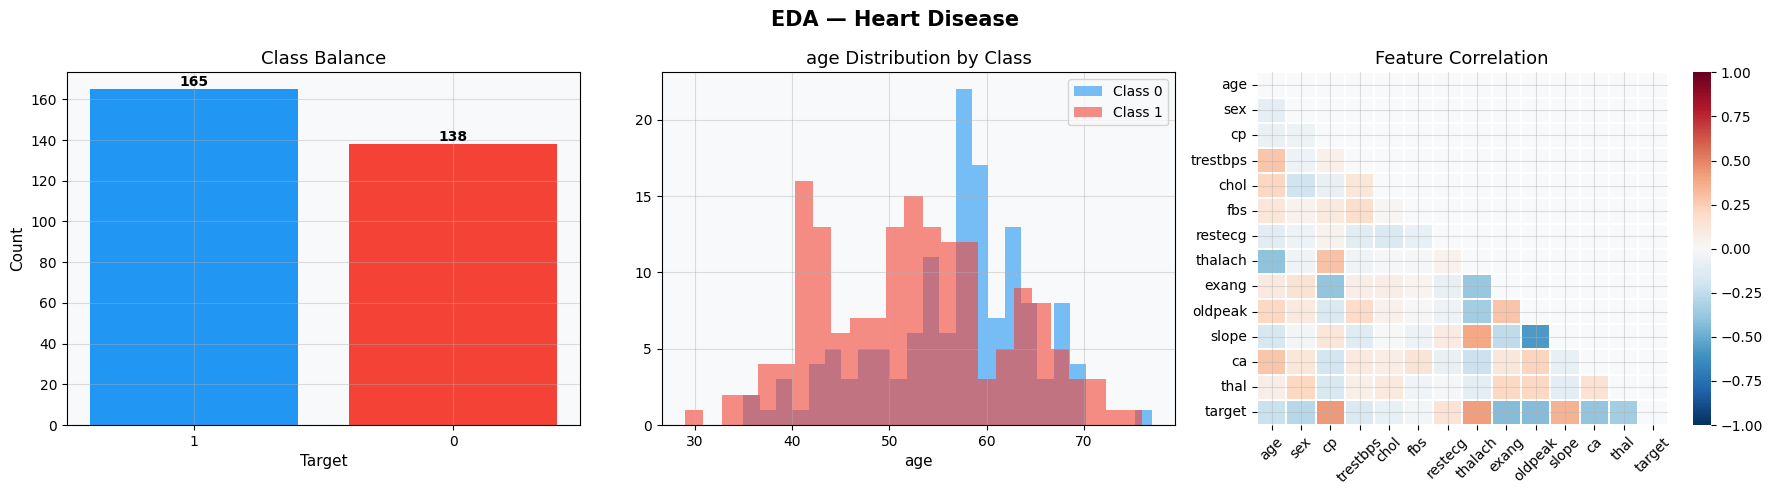

     Saved: /content/drive/MyDrive/CardioAI/plots/eda_heart_disease.png

════════════════════════════════════════════════════════════
  EDA: Cardiovascular Dataset
════════════════════════════════════════════════════════════
Shape      : (70000, 13)
Duplicates : 0

Null counts:
  None

Dtypes:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64

Descriptive stats:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


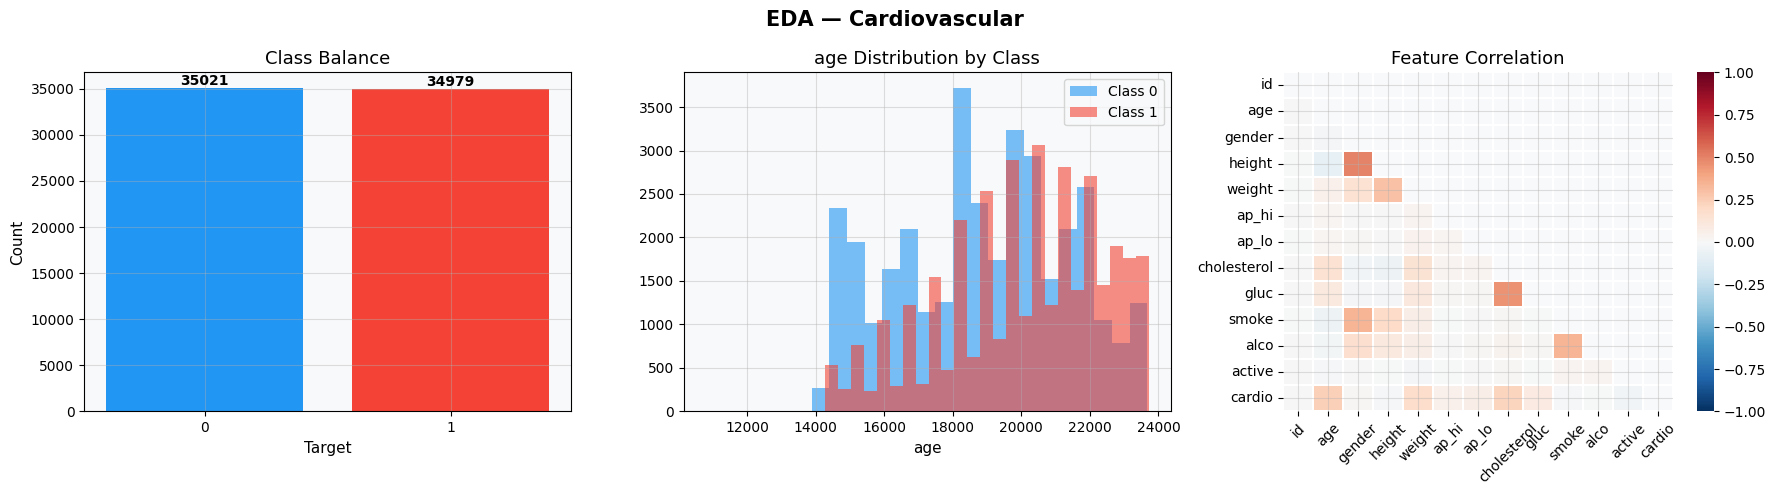

     Saved: /content/drive/MyDrive/CardioAI/plots/eda_cardiovascular.png


In [ ]:
# (EDA) Exploratory Data Analysis
#| age | sex | chol | target |
# | --- | --- | ---- | ------ |
# | 63  | 1   | 233  | 1      |
# | 37  | 1   | 250  | 0      |
# | 41  | 0   | 204  | 0      |
# | 56  | 1   | 290  | 1      |

# آیا داده خراب است؟
# آیا داده ناقص است؟
# آیا داده تکراری است؟
# آیا کلاس‌ها متعادل هستند؟
# کدام ستون‌ها به هم مرتبط‌اند؟


def eda_summary(df: pd.DataFrame, name: str) -> None:
    print(f'\n{"═"*60}')
    print(f'  EDA: {name}')
    print(f'{"═"*60}')
    print(f'Shape      : {df.shape}')
    print(f'Duplicates : {df.duplicated().sum()}') # jتکراری
    print(f'\nNull counts:')
    nulls = df.isnull().sum() 
    print(nulls[nulls > 0].to_string() if nulls.any() else '  None') # ستون های نال
    print(f'\nDtypes:\n{df.dtypes.to_string()}')
    print(f'\nDescriptive stats:')
    display(df.describe())

def plot_eda(df: pd.DataFrame, target_col: str, name: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'EDA — {name}', fontsize=15, fontweight='bold')

    # ── Class balance ──────────────────────────────────────
    counts = df[target_col].value_counts()
    colors = ['#2196F3', '#F44336']
    axes[0].bar(counts.index.astype(str), counts.values, color=colors)
    axes[0].set_title('Class Balance')
    axes[0].set_xlabel('Target')
    axes[0].set_ylabel('Count')
    for i, (idx, val) in enumerate(counts.items()):
        axes[0].text(i, val + counts.max() * 0.01, str(val),
                     ha='center', fontweight='bold')
# مدل ممکن است همیشه 0 پیش‌بینی کند.
    # ── Age distribution ──────────────────────────────────
    age_col = 'age' if 'age' in df.columns else df.select_dtypes('number').columns[0]
    for label, grp in df.groupby(target_col)[age_col]: # گروه بندی سن بر اساس تارگت
        color = '#2196F3' if label == 0 else '#F44336'
        axes[1].hist(grp, bins=25, alpha=0.6, color=color, label=f'Class {label}')
    axes[1].set_title(f'{age_col} Distribution by Class')
    axes[1].set_xlabel(age_col)
    axes[1].legend()
# سالم ها ← جوان تر
# بیمارها ← مسن تر
    # ── Correlation heatmap ─────────────────────────────── ماتریس همبستگی
    num_cols = df.select_dtypes(include='number').columns.tolist() # گرفتن سلول های عددی
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=axes[2], cmap='RdBu_r',
                center=0, vmin=-1, vmax=1,
                annot=len(num_cols) <= 12,
                fmt='.1f', linewidths=0.3,
                annot_kws={'size': 7})
    axes[2].set_title('Feature Correlation')
    axes[2].tick_params(axis='x', rotation=45)
# یجورایی هم صحت سنجی 
# کدام Feature ها ارزش دارند؟
    plt.tight_layout()
    save_path = f"{PATHS['plots']}/eda_{name.replace(' ', '_').lower()}.png"
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'     Saved: {save_path}')

eda_summary(df_hd, 'Heart Disease Dataset')
plot_eda(df_hd, 'target', 'Heart Disease')

eda_summary(df_cv, 'Cardiovascular Dataset')
plot_eda(df_cv, 'cardio', 'Cardiovascular')

In [ ]:
# ============================================================ Data Cleaning & Repair

class MedicalDataCleaner:
    """
    Production-grade medical data cleaning pipeline.
    Each cleaning step logs what was removed / corrected.
    """

    def __init__(self, df: pd.DataFrame, dataset_name: str):
        self.df   = df.copy()
        self.name = dataset_name
        self.log  = []
        self._original_shape = df.shape

    def _record(self, step: str, before: int, after: int) -> None:
        removed = before - after
        self.log.append({'step': step, 'before': before,
                        'after': after, 'removed': removed})
        print(f'   [{step}]  rows: {before:,} → {after:,}  (removed {removed:,})')

    # ──  Remove exact duplicates ─────────────────────
    def remove_duplicates(self):
        before = len(self.df)
        self.df = self.df.drop_duplicates()
        self._record('remove_duplicates', before, len(self.df))
        return self
    # اگر یک بیمار 50 بار تکرار شود مدل فکر می‌کند آن بیمار خیلی مهم است.
    # ──   Convert age from days → years (Cardiovascular) ─
    def fix_age_days_to_years(self):
        """
        The Cardiovascular dataset stores age in DAYS.
        Realistic age in days: ~7300 (20 yr) to ~36500 (100 yr).
        Convert if median > 1000.
        """
        if 'age' not in self.df.columns:
            return self
        median_age = self.df['age'].median()
        if median_age > 1000:
            self.df['age'] = (self.df['age'] / 365.25).round(1)
            print(f'   [fix_age] Converted age from days to years. '
                  f'New median: {self.df["age"].median():.1f} yrs')
        return self

    # ──   Remove impossible physiological values ───────
    def remove_impossible_values(self):
        before = len(self.df)
        df = self.df.copy()

        # Age: 18-120 years
        if 'age' in df.columns:
            df = df[df['age'].between(18, 120)]
        # فشار خون
        # Blood pressure (Heart Disease dataset)
        if 'trestbps' in df.columns:
            df = df[df['trestbps'].between(60, 250)]

        # Blood pressure systolic / diastolic (Cardiovascular dataset)
        if 'ap_hi' in df.columns:
            df = df[df['ap_hi'].between(60, 300)]
        if 'ap_lo' in df.columns:
            df = df[df['ap_lo'].between(40, 200)]
        # Systolic must be > diastolic
        if 'ap_hi' in df.columns and 'ap_lo' in df.columns:
            df = df[df['ap_hi'] > df['ap_lo']]

        # Cholesterol (Heart Disease dataset, mg/dL)
        if 'chol' in df.columns:
            df = df[(df['chol'] > 100) & (df['chol'] < 600)]

        # Resting heart rate
        if 'thalach' in df.columns:
            df = df[df['thalach'].between(40, 220)]

        # Weight (kg) & Height (cm)
        if 'weight' in df.columns:
            df = df[df['weight'].between(30, 250)]
        if 'height' in df.columns:
            df = df[df['height'].between(100, 230)]

        # No negative values allowed anywhere
        num_cols = df.select_dtypes(include='number').columns
        for col in num_cols:
            if col not in ['target', 'cardio', 'exang']:
                df = df[df[col] >= 0]

        self.df = df
        self._record('impossible_values', before, len(self.df))
        return self

    # ──  Remove statistical outliers (IQR method) ────
    def remove_outliers_iqr(self, cols: Optional[list] = None,
                            factor: float = 3.5) -> 'MedicalDataCleaner':
        """
        Conservative IQR factor (3.5) — remove only extreme outliers
        to preserve rare but real medical cases.
        """
        # ممکن است واقعی باشد
        before = len(self.df)
        if cols is None:
            cols = self.df.select_dtypes(include='number').columns.tolist()
            # Exclude binary / target cols
            exclude = ['target', 'cardio', 'sex', 'gender', 'fbs',
                       'exang', 'smoke', 'alco', 'active',
                       'cholesterol', 'gluc']
            cols = [c for c in cols if c not in exclude]

        mask = pd.Series([True] * len(self.df), index=self.df.index)
        for col in cols:
            Q1, Q3 = self.df[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lo  = Q1 - factor * IQR
            hi  = Q3 + factor * IQR
            mask &= self.df[col].between(lo, hi)
        # Q1 یعنی
        # ۲۵ درصد داده‌ها از این مقدار کمترند.
        # Q3 یعنی
        # ۷۵ درصد داده‌ها از این مقدار کمترند.
            # IQR = Q3 - Q1
        #محاسبه حد بالا و حد پایین 
        #حدف اعداد خارج از محدوده

        # و حذف می‌شود
        self.df = self.df[mask]
        self._record(f'outliers_IQR_x{factor}', before, len(self.df))
        return self

    # ──   Handle remaining nulls ───────────────────────
    def handle_nulls(self, strategy: str = 'median') -> 'MedicalDataCleaner':

        thresh = int(0.7 * len(self.df.columns)) # x=0.7 * COL THEN if x>!null -> بیمار و نگه دار 
        before = len(self.df)
        self.df = self.df.dropna(thresh=thresh)
        self._record('drop_high_null_rows', before, len(self.df))

        # Impute remaining
        num_cols = self.df.select_dtypes(include='number').columns
        for col in num_cols:
            if self.df[col].isnull().any():
                self.df[col].fillna(self.df[col].median(), inplace=True)

        cat_cols = self.df.select_dtypes(exclude='number').columns
        for col in cat_cols:
            if self.df[col].isnull().any():
                self.df[col].fillna(self.df[col].mode()[0], inplace=True)

        print(f'   [handle_nulls] Remaining nulls: {self.df.isnull().sum().sum()}')
        return self

    # ──  Encode categorical columns ──────────────────
    def encode_categoricals(self) -> 'MedicalDataCleaner':
        cat_cols = self.df.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col].astype(str))
            print(f'   [encode] {col}: {list(le.classes_)}')
        return self
    # اگر 70٪ ستون‌ها خالی باشند حذف می‌شود.
    # ──  Reset index and finalize ─────────────────────
    def finalize(self) -> pd.DataFrame:
        self.df = self.df.reset_index(drop=True)
        print(f'\n      Cleaning complete: {self._original_shape} → {self.df.shape}')
        print(f'   Retained: {len(self.df)/self._original_shape[0]*100:.1f}%')
        return self.df
    # ریست ایندکس:
    def print_log(self):
        print(f'\n{"─"*55}')
        print(f'  Cleaning log — {self.name}')
        print(f'{"─"*55}')
        for entry in self.log:
            print(f"  {entry['step']:<30} removed {entry['removed']:>5}")


# ── Run cleaning ──────────────────────────────────────────
print('  Cleaning Heart Disease dataset...')
cleaner_hd = (
    MedicalDataCleaner(df_hd, 'Heart Disease')
    .remove_duplicates()
    .remove_impossible_values()
    .remove_outliers_iqr()
    .handle_nulls()
    .encode_categoricals()
)
df_hd_clean = cleaner_hd.finalize()
cleaner_hd.print_log()

print('\n  Cleaning Cardiovascular dataset...')
cleaner_cv = (
    MedicalDataCleaner(df_cv, 'Cardiovascular')
    .remove_duplicates()
    .fix_age_days_to_years()
    .remove_impossible_values()
    .remove_outliers_iqr()
    .handle_nulls()
    .encode_categoricals()
)
df_cv_clean = cleaner_cv.finalize()
cleaner_cv.print_log()

# ── Save cleaned datasets to Drive ────────────────────────
df_hd_clean.to_csv(f"{PATHS['cleaned']}/heart_disease_clean.csv", index=False)
df_cv_clean.to_csv(f"{PATHS['cleaned']}/cardiovascular_clean.csv", index=False)
print(f'\n  Cleaned datasets saved to: {PATHS["cleaned"]}')

  Cleaning Heart Disease dataset...
   [remove_duplicates]  rows: 303 → 302  (removed 1)
   [impossible_values]  rows: 302 → 302  (removed 0)
   [outliers_IQR_x3.5]  rows: 302 → 301  (removed 1)
   [drop_high_null_rows]  rows: 301 → 301  (removed 0)
   [handle_nulls] Remaining nulls: 0

      Cleaning complete: (303, 14) → (301, 14)
   Retained: 99.3%

───────────────────────────────────────────────────────
  Cleaning log — Heart Disease
───────────────────────────────────────────────────────
  remove_duplicates              removed     1
  impossible_values              removed     0
  outliers_IQR_x3.5              removed     1
  drop_high_null_rows            removed     0

  Cleaning Cardiovascular dataset...
   [remove_duplicates]  rows: 70,000 → 70,000  (removed 0)
   [fix_age] Converted age from days to years. New median: 53.9 yrs
   [impossible_values]  rows: 70,000 → 68,639  (removed 1,361)
   [outliers_IQR_x3.5]  rows: 68,639 → 68,424  (removed 215)
   [drop_high_null_rows] 

     Engineering features for Heart Disease dataset...
   ✓ bp_category                  — Resting BP category  (0=Normal … 4=Crisis)
   ✓ rate_pressure_product        — Rate-Pressure Product  (myocardial O₂ demand)
   ✓ chronotropic_index           — Chronotropic Index  (exercise HR response)
   ✓ st_depression_index          — ST-Depression Index  (ischemia marker)
   ✓ age_st_depression            — Age × ST-depression interaction

      Feature engineering complete.
   New features (5): ['bp_category', 'rate_pressure_product', 'chronotropic_index', 'st_depression_index', 'age_st_depression']
   Final shape: (301, 19)

     Engineering features for Cardiovascular dataset...
   ✓ bmi                          — Body Mass Index  [kg/m²]
   ✓ bmi_category                 — WHO BMI category  (0=Underweight, 5=Obese III)
   ✓ map                          — Mean Arterial Pressure  [mmHg]
   ✓ pulse_pressure               — Pulse Pressure  [mmHg]  (arterial stiffness marker)
   ✓ hypertensi

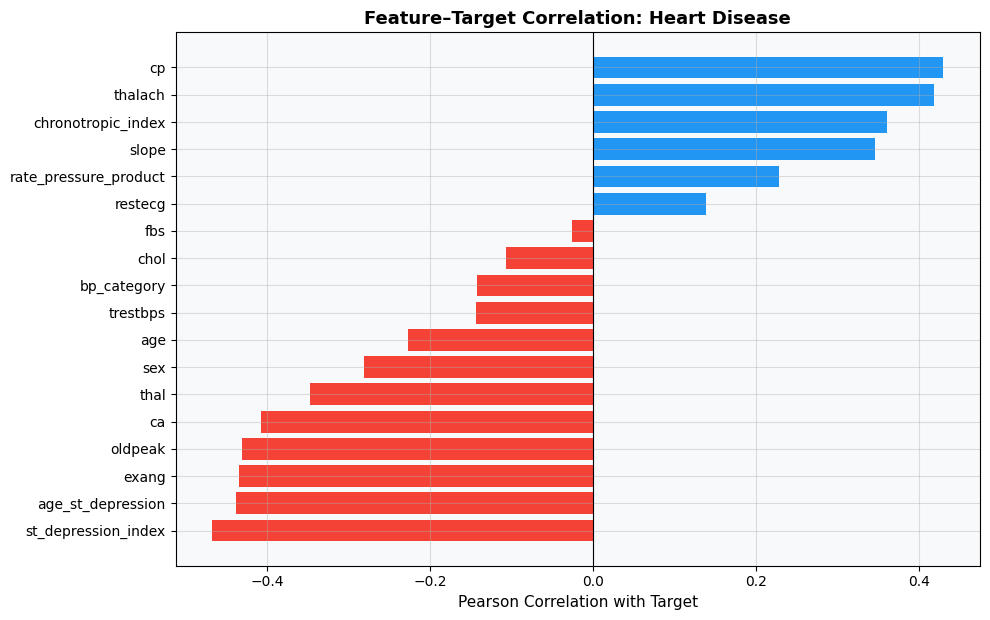

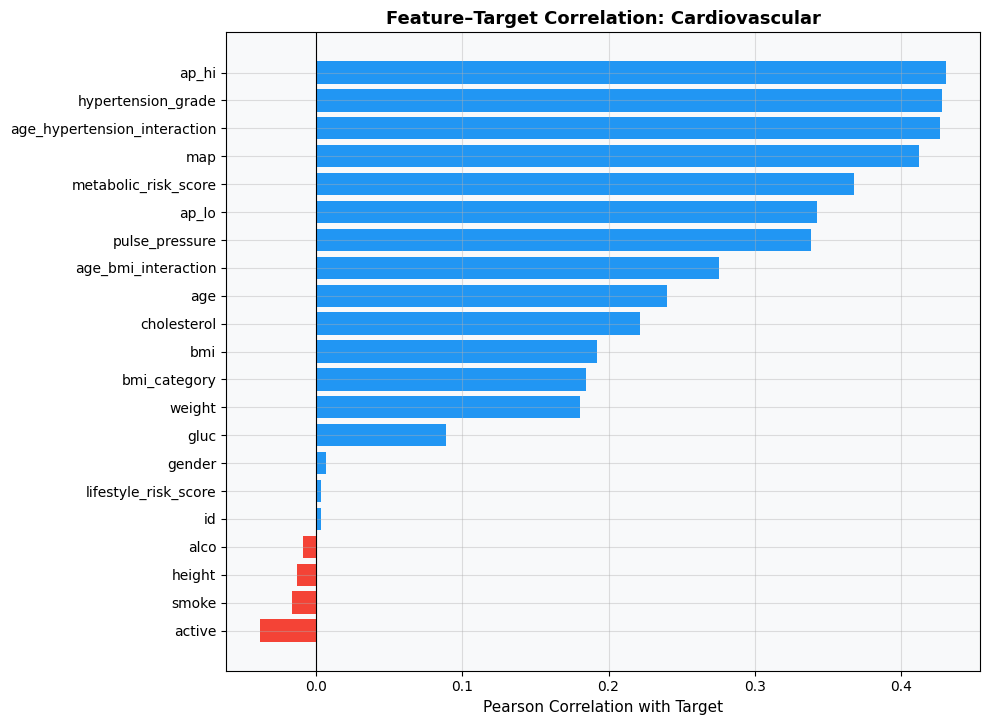

In [ ]:
# Medical Feature Engineering

class MedicalFeatureEngineer:

    def __init__(self, df: pd.DataFrame, dataset_name: str):
        self.df   = df.copy()
        self.name = dataset_name
        self.new_features: List[str] = []

    def _add(self, col_name: str, values, description: str) -> None:
        self.df[col_name] = values
        self.new_features.append(col_name)
        print(f'   ✓ {col_name:<28} — {description}')

    # ─────────────────────────────────────────────────────
    # Features for CARDIOVASCULAR dataset
    # (has ap_hi فشار سیستنولیک, ap_lo فشار دیاستولیک, weight, height, cholesterol, gluc قند خون)
    # ─────────────────────────────────────────────────────

    def add_bmi(self):
        """BMI = weight(kg) / height(m)²"""
        if 'weight' in self.df.columns and 'height' in self.df.columns:
            h_m = self.df['height'] / 100.0
            bmi = self.df['weight'] / (h_m ** 2)
            self._add('bmi', bmi.round(2),
                    'Body Mass Index  [kg/m²]')

            # Obesity category
            bins   = [0, 18.5, 25, 30, 35, 40, np.inf]
            labels = [0, 1, 2, 3, 4, 5]  
            self._add('bmi_category',
                    pd.cut(bmi, bins=bins, labels=labels).astype(float),
                    ' BMI category  (0=Underweight, 5=Obese III)')
        return self

    def add_blood_pressure_features(self):
        if 'ap_hi' in self.df.columns and 'ap_lo' in self.df.columns:
            s, d = self.df['ap_hi'], self.df['ap_lo']
            # 
            # Mean Arterial Pressure: MAP = DBP + (SBP-DBP)/3  میانگین فشار شریانی
            map_val = d + (s - d) / 3
            self._add('map', map_val.round(2),
                    'Mean Arterial Pressure  [mmHg]')

            # Pulse Pressure: PP = SBP - DBP فشار نبض 
            self._add('pulse_pressure', (s - d).round(2),
                    'Pulse Pressure  [mmHg]  (arterial stiffness marker)')

            # Hypertension grade (ESC/ESH guidelines) درجه پر فشاری خون 
            # 0=Normal, 1=High-normal, 2=Grade1, 3=Grade2, 4=Grade3
            def ht_grade(row):
                sbp, dbp = row['ap_hi'], row['ap_lo']
                if sbp >= 180 or dbp >= 110: return 4
                if sbp >= 160 or dbp >= 100: return 3
                if sbp >= 140 or dbp >= 90:  return 2
                if sbp >= 130 or dbp >= 85:  return 1
                return 0
            self._add('hypertension_grade',
                    self.df.apply(ht_grade, axis=1),
                    'ESC/ESH Hypertension grade  (0-4)')

        # Heart Disease dataset uses trestbps دسته بندی فشار خون استراحت 
        if 'trestbps' in self.df.columns:
            self._add('bp_category',
                      pd.cut(self.df['trestbps'],
                             bins=[0, 120, 130, 140, 160, np.inf],
                             labels=[0, 1, 2, 3, 4]).astype(float),
                      'Resting BP category  (0=Normal … 4=Crisis)')
        return self

    def add_metabolic_risk_score(self):

        score = pd.Series(0.0, index=self.df.index) # همه اول 0

        if 'bmi' in self.df.columns:
            score += (self.df['bmi'] > 30).astype(float) * 2.0   #+2
            score += (self.df['bmi'] > 35).astype(float) * 1.5  #+1.5

        if 'hypertension_grade' in self.df.columns:
            score += self.df['hypertension_grade'] * 1.5

        if 'cholesterol' in self.df.columns:
            # Cholesterol in CV dataset: 1=normal, 2=above normal, 3=well above
            score += (self.df['cholesterol'] - 1) * 2.0

        if 'gluc' in self.df.columns:
            score += (self.df['gluc'] - 1) * 1.5

        if 'smoke' in self.df.columns:
            score += self.df['smoke'] * 3.0

        if 'alco' in self.df.columns:
            score += self.df['alco'] * 1.5

        if score.sum() > 0:
            self._add('metabolic_risk_score', score.round(2),
                      'Composite metabolic risk  (higher = worse)')
        return self

    def add_cardiac_stress_index(self):
        """میزان بار کاری قلب Stress Index (Heart Disease dataset). thalach : حداکثر ضربان قلب    """
        if 'thalach' in self.df.columns and 'trestbps' in self.df.columns:
            # (thalach حداکثر ضربان قلب) * (trestbps دسته بندی فشار خون استراحت) )/100
            rpp = (self.df['thalach'] * self.df['trestbps']) / 100
            self._add('rate_pressure_product', rpp.round(2),
                      'Rate-Pressure Product  (myocardial O₂ demand)')

        if 'thalach' in self.df.columns and 'age' in self.df.columns:
            # توانایی قلب به فعالیت بدنی
            max_hr = 220 - self.df['age']
            ci = self.df['thalach'] / max_hr
            self._add('chronotropic_index', ci.round(3),
                      'Chronotropic Index  (exercise HR response)')

        if 'oldpeak' in self.df.columns and 'thalach' in self.df.columns:
            #oldpeak/(thalach/100) شاخصی ازایسکمی قلب
            self._add('st_depression_index',
                      (self.df['oldpeak'] / (self.df['thalach'] / 100)).round(3),
                      'ST-Depression Index  (ischemia marker)')
        return self

    def add_lifestyle_risk_score(self):
        """Lifestyle Risk Score for Cardiovascular dataset."""
        score = pd.Series(0.0, index=self.df.index)

        if 'smoke' in self.df.columns:
            score += self.df['smoke'] * 3.0
        if 'alco' in self.df.columns:
            score += self.df['alco'] * 2.0
        if 'active' in self.df.columns:
            score -= self.df['active'] * 1.5 

        if score.abs().sum() > 0:
            self._add('lifestyle_risk_score', score.round(2),
                      'Lifestyle Risk Score  (positive = higher risk)')
        return self

    def add_age_risk_interaction(self):
        """Age × risk factor interaction terms."""
        if 'age' not in self.df.columns:
            return self

        if 'bmi' in self.df.columns:
            self._add('age_bmi_interaction',
                      (self.df['age'] * self.df['bmi'] / 100).round(3),
                      'Age × BMI interaction')

        if 'hypertension_grade' in self.df.columns:
            self._add('age_hypertension_interaction',
                      (self.df['age'] * self.df['hypertension_grade']).round(2),
                      'Age × Hypertension interaction')

        if 'oldpeak' in self.df.columns:
            self._add('age_st_depression',
                      (self.df['age'] * self.df['oldpeak']).round(3),
                      'Age × ST-depression interaction')
        return self

    def finalize(self) -> pd.DataFrame:
        print(f'\n      Feature engineering complete.')
        print(f'   New features ({len(self.new_features)}): {self.new_features}')
        print(f'   Final shape: {self.df.shape}')
        return self.df


# ── Engineer features ─────────────────────────────────────
print('     Engineering features for Heart Disease dataset...')
eng_hd = (
    MedicalFeatureEngineer(df_hd_clean, 'Heart Disease')
    .add_blood_pressure_features()
    .add_cardiac_stress_index()
    .add_age_risk_interaction()
)
df_hd_eng = eng_hd.finalize()

print('\n     Engineering features for Cardiovascular dataset...')
eng_cv = (
    MedicalFeatureEngineer(df_cv_clean, 'Cardiovascular')
    .add_bmi()
    .add_blood_pressure_features()
    .add_metabolic_risk_score()
    .add_lifestyle_risk_score()
    .add_age_risk_interaction()
)
df_cv_eng = eng_cv.finalize()

# ── Save engineered datasets ──────────────────────────────
df_hd_eng.to_csv(f"{PATHS['engineered']}/heart_disease_engineered.csv", index=False)
df_cv_eng.to_csv(f"{PATHS['engineered']}/cardiovascular_engineered.csv", index=False)
print(f'\n Engineered datasets saved to: {PATHS["engineered"]}')

# ── Feature correlation with target ───────────────────────
def plot_feature_importance_corr(df, target_col, title, save_path):
    num_df = df.select_dtypes(include='number')
    corr = num_df.corr()[target_col].drop(target_col).sort_values()
    colors = ['#F44336' if v < 0 else '#2196F3' for v in corr.values]

    fig, ax = plt.subplots(figsize=(10, max(6, len(corr) * 0.35)))
    ax.barh(corr.index, corr.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature–Target Correlation: {title}', fontweight='bold')
    ax.set_xlabel('Pearson Correlation with Target')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

plot_feature_importance_corr(df_hd_eng, 'target', 'Heart Disease',
    f"{PATHS['plots']}/feature_corr_hd.png")
plot_feature_importance_corr(df_cv_eng, 'cardio', 'Cardiovascular',
    f"{PATHS['plots']}/feature_corr_cv.png")


════════════════════════════════════════════════════════════
  Training on: Heart Disease
  Train: (240, 18)  Test: (61, 18)
════════════════════════════════════════════════════════════

  ▶ Training XGBoost...
    CV AUC: 0.9133 ± 0.0354
    Test AUC:0.8485  F1:0.7576  Prec:0.7576  Rec:0.7576

  ▶ Training CatBoost...
    CV AUC: 0.9003 ± 0.0500
    Test AUC:0.8571  F1:0.7714  Prec:0.7297  Rec:0.8182

  ▶ Training LightGBM...
    CV AUC: 0.9052 ± 0.0343
    Test AUC:0.8442  F1:0.7385  Prec:0.7500  Rec:0.7273

  ▶ Training LogisticRegression...
    CV AUC: 0.8990 ± 0.0672
    Test AUC:0.8712  F1:0.8000  Prec:0.7568  Rec:0.8485

════════════════════════════════════════════════════════════
  Training on: Cardiovascular
  Train: (54739, 20)  Test: (13685, 20)
════════════════════════════════════════════════════════════

  ▶ Training XGBoost...
    CV AUC: 0.7999 ± 0.0044
    Test AUC:0.7995  F1:0.7180  Prec:0.7524  Rec:0.6866

  ▶ Training CatBoost...
    CV AUC: 0.8014 ± 0.0044
    Test

,roc_auc,f1,precision,recall,cv_auc_mean,cv_auc_std
model,,,,,,
XGBoost,0.8485,0.7576,0.7576,0.7576,0.9133,0.0354
CatBoost,0.8571,0.7714,0.7297,0.8182,0.9003,0.0500
LightGBM,0.8442,0.7385,0.7500,0.7273,0.9052,0.0343
LogisticRegression,0.8712,0.8000,0.7568,0.8485,0.8990,0.0672



  Cardiovascular — Model Comparison


,roc_auc,f1,precision,recall,cv_auc_mean,cv_auc_std
model,,,,,,
XGBoost,0.7995,0.7180,0.7524,0.6866,0.7999,0.0044
CatBoost,0.8022,0.7201,0.7602,0.6840,0.8014,0.0044
LightGBM,0.8000,0.7185,0.7527,0.6872,0.8000,0.0044
LogisticRegression,0.7957,0.7184,0.7441,0.6945,0.7946,0.0038


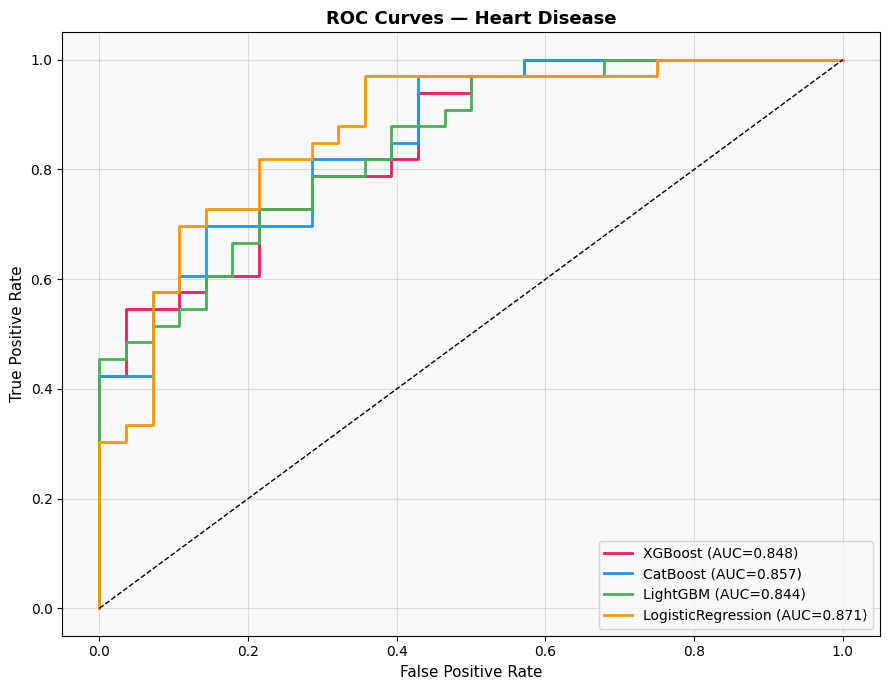

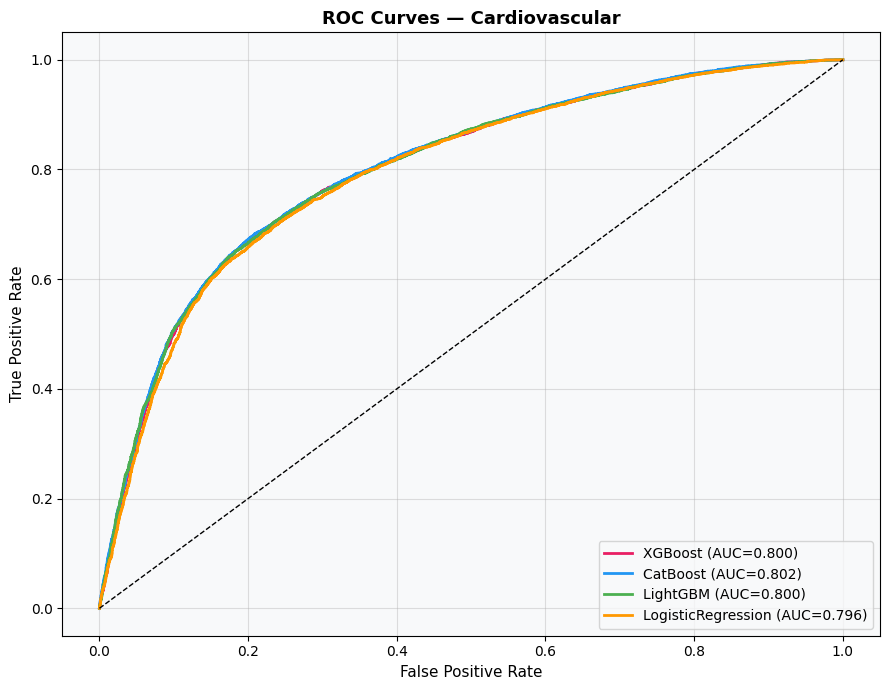

In [ ]:
#  Model Training
# Trains XGBoost, CatBoost, LightGBM, Logistic Regression
# on BOTH datasets with 5-fold stratified cross-validation.
# ============================================================

def prepare_data(df: pd.DataFrame, target_col: str):
    # REMOVE ID , TARGET
    drop_cols = [target_col, 'id'] if 'id' in df.columns else [target_col]
    X = df.drop(columns=drop_cols) # extract data
    y = df[target_col].astype(int)

    X_train, X_test, y_train, y_test = train_test_split( # 80 20  x : main part  , y : target
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y # حفط نسبت
    )
    return X_train, X_test, y_train, y_test, list(X.columns)


def evaluate_model(model, X_test, y_test, name: str) -> Dict:
    y_pred  = model.predict(X_test) # پیش بینی برای هر کلیه داده‌ها
    #احتماع تعلق ب کلاس 
    y_proba = model.predict_proba(X_test)[:, 1] \
            if hasattr(model, 'predict_proba') else y_pred
    # roc_auc هرچی به 1 نزدیکتر باشه بهتره 
    metrics = {
        'model'    : name,
        'roc_auc'  : roc_auc_score(y_test, y_proba),
        'f1'       : f1_score(y_test, y_pred), # میانگین بین حساسیت  و دقت یعنی همین دوتا پایینی
        'precision': precision_score(y_test, y_pred), # از بین تشخصی بیار چند درصد واقعا بیمار بودن 
        'recall'   : recall_score(y_test, y_pred), # از بین مورد‌های واقعی بیمار بودن چند تا هم درست شناسایی شده است.
    }
    return metrics


def train_all_models(X_train, X_test, y_train, y_test,
                    dataset_name: str, scaler=None) -> Dict:

    print(f'\n{"═"*60}')
    print(f'  Training on: {dataset_name}')
    print(f'  Train: {X_train.shape}  Test: {X_test.shape}')
    print(f'{"═"*60}')

    n_pos = y_train.sum() # تعداد نمونه های کلاس 1 یعنی بیمار ها
    n_neg = len(y_train) - n_pos # تعداد مریض ها 
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0 # نسبت مریض ها به سالن ها 

    # ── Scale features for LR ─────────────────────────────
    if scaler is None:
        scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train) # میانگین و انحراف معیار را یاد می‌گیرد
    X_test_sc  = scaler.transform(X_test)  # روی تست از همون میانگین استفاده میشه 

    # ── Model definitions ─────────────────────────────────
    models = {
        'XGBoost': XGBClassifier(
            n_estimators=400, # 400 درخت
            max_depth=5, learning_rate=0.05,
            subsample=0.8, # 0.8 درصد داده ها در هر درخت 
            colsample_bytree=0.8, # 0.8 درصد ویژگی ها انتخاب میشه
            scale_pos_weight=scale_pos_weight, # اون نسبت وزن 
            random_state=RANDOM_STATE, eval_metric='logloss',
            verbosity=0 # عدم چاپ پیام اضافی
        ),
        'CatBoost': CatBoostClassifier(
            iterations=400, # 400 مرحله
            depth=6, learning_rate=0.05,
            l2_leaf_reg=3, # پارامتر برای جلوگیری از Overfitting
            random_state=RANDOM_STATE,
            verbose=0, eval_metric='AUC'
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            num_leaves=31, # حداکثر تعداد برگ
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE, verbose=-1
        ),
        'LogisticRegression': LogisticRegression(
            max_iter=1000, # 1000 تکرار
            C=1.0, #پارامتر Regularization.
            class_weight='balanced', # وزندهی خودکار
            random_state=RANDOM_STATE
        ),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    trained_models = {}
    all_metrics    = []
    lr_models      = {'LogisticRegression'}  # use scaled data

    for name, model in models.items():
        X_tr = X_train_sc if name in lr_models else X_train.values
        X_te = X_test_sc  if name in lr_models else X_test.values

        print(f'\n  ▶ Training {name}...')
        # 5-fold CV AUC
        cv_scores = cross_val_score( # 5 بار ترین هر بار یک قسمت 
            model, X_tr, y_train, cv=cv,
            scoring='roc_auc', n_jobs=-1
        )
        print(f'    CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

        # Final fit on full training set
        model.fit(X_tr, y_train) #ترین روی کل بعد از اون 5 بار 
        trained_models[name] = model

        # Test set evaluation
        metrics = evaluate_model(model, X_te, y_test, name)
        metrics['cv_auc_mean'] = cv_scores.mean() #ذخیره میانگین Cross Validation
        metrics['cv_auc_std']  = cv_scores.std()# ذخیره انحراف معیار Cross Validation
        all_metrics.append(metrics)
        print(f'    Test AUC:{metrics["roc_auc"]:.4f}  '
              f'F1:{metrics["f1"]:.4f}  '
              f'Prec:{metrics["precision"]:.4f}  '
              f'Rec:{metrics["recall"]:.4f}')

    metrics_df = pd.DataFrame(all_metrics).set_index('model')
    return trained_models, metrics_df, scaler, X_test, y_test, X_test_sc


# ── Prepare datasets ──────────────────────────────────────
Xtr_hd, Xte_hd, ytr_hd, yte_hd, feat_hd = prepare_data(df_hd_eng, 'target')
Xtr_cv, Xte_cv, ytr_cv, yte_cv, feat_cv = prepare_data(df_cv_eng, 'cardio')

# ── Train ─────────────────────────────────────────────────
models_hd, metrics_hd, scaler_hd, Xte_hd, yte_hd, Xte_hd_sc = \
    train_all_models(Xtr_hd, Xte_hd, ytr_hd, yte_hd, 'Heart Disease')

models_cv, metrics_cv, scaler_cv, Xte_cv, yte_cv, Xte_cv_sc = \
    train_all_models(Xtr_cv, Xte_cv, ytr_cv, yte_cv, 'Cardiovascular')

# ── Print comparison tables ───────────────────────────────
print('\n  Heart Disease — Model Comparison')
display(metrics_hd.round(4))
print('\n  Cardiovascular — Model Comparison')
display(metrics_cv.round(4))

# ── Plot ROC curves ───────────────────────────────────────
def plot_roc_curves(models_dict, X_test, y_test, lr_X_test_sc, title, save_path):
    lr_set = {'LogisticRegression'}
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']

    for (name, model), color in zip(models_dict.items(), colors):
        X = lr_X_test_sc if name in lr_set else X_test.values
        proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}', fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

plot_roc_curves(models_hd, Xte_hd, yte_hd, Xte_hd_sc,
    'Heart Disease', f"{PATHS['plots']}/roc_heart_disease.png")
plot_roc_curves(models_cv, Xte_cv, yte_cv, Xte_cv_sc,
    'Cardiovascular', f"{PATHS['plots']}/roc_cardiovascular.png")


════════════════════════════════════════════════════════════
  Building Ensemble — Heart Disease
════════════════════════════════════════════════════════════

  ▶ Soft Voting
    AUC:0.8593  F1:0.7576  Prec:0.7576  Rec:0.7576

  ▶ Stacking (XGB+Cat+LGB → LR meta)
    AUC:0.8582  F1:0.7576  Prec:0.7576  Rec:0.7576


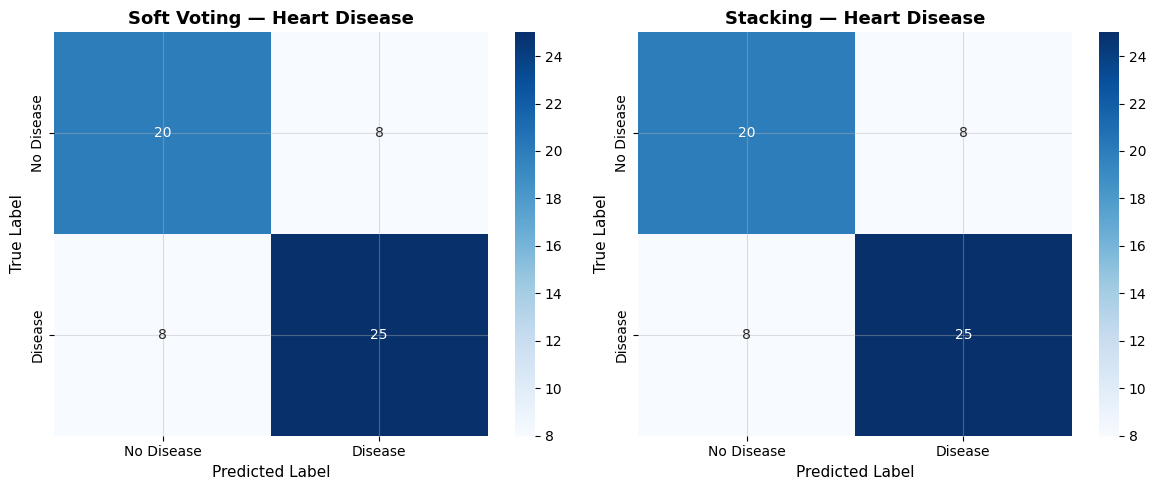


════════════════════════════════════════════════════════════
  Building Ensemble — Cardiovascular
════════════════════════════════════════════════════════════

  ▶ Soft Voting
    AUC:0.8013  F1:0.7214  Prec:0.7540  Rec:0.6915

  ▶ Stacking (XGB+Cat+LGB → LR meta)
    AUC:0.7833  F1:0.7107  Prec:0.7355  Rec:0.6875


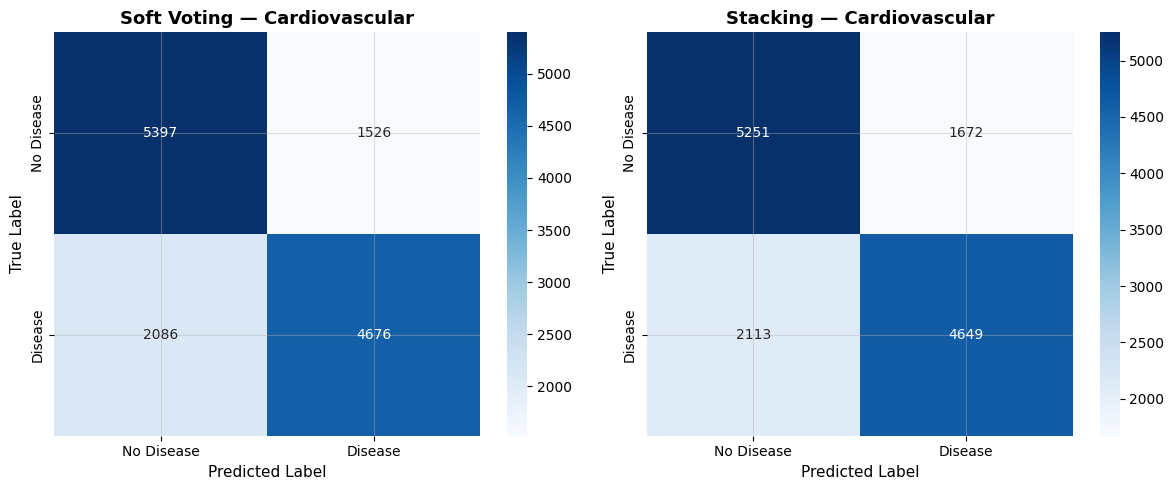


  All models saved to: /content/drive/MyDrive/CardioAI/models


In [ ]:
# ============================================================ Ensemble: Soft Voting + Stacking

def build_ensemble(trained_models: Dict, X_train, y_train,
                   X_test, y_test, dataset_name: str,
                   scaler, X_test_sc) -> Dict:
    """
    Build two ensemble strategies:
      1. Soft Voting   — average predicted probabilities
      2. Stacking      — meta-learner (LR) on top of base models
    """
    print(f'\n{"═"*60}')
    print(f'  Building Ensemble — {dataset_name}')
    print(f'{"═"*60}')

    lr_set = {'LogisticRegression'}

    # ── Manual Soft Voting ────────────────────────────────
    # Average probabilities from all base models
    probas = []
    for name, model in trained_models.items():
        X = X_test_sc if name in lr_set else X_test.values
        p = model.predict_proba(X)[:, 1] # احتمال هر مدل
        probas.append(p)

    avg_proba = np.mean(probas, axis=0) # میانگین خروجی همه مدل ها برای ی نفر
    avg_pred  = (avg_proba >= 0.5).astype(int) #اگر از نیم بیشتر باشه بیماره 

    voting_metrics = {
        'model'    : 'SoftVoting',
        'roc_auc'  : roc_auc_score(y_test, avg_proba),
        'f1'       : f1_score(y_test, avg_pred),
        'precision': precision_score(y_test, avg_pred),
        'recall'   : recall_score(y_test, avg_pred),
    }
    print(f'\n  ▶ Soft Voting')
    print(f'    AUC:{voting_metrics["roc_auc"]:.4f}  '
          f'F1:{voting_metrics["f1"]:.4f}  '
          f'Prec:{voting_metrics["precision"]:.4f}  '
          f'Rec:{voting_metrics["recall"]:.4f}')

    # ── Stacking ──────────────────────────────────────────
    # Use XGBoost, CatBoost, LightGBM as base; LR as meta
    # NOTE: For simplicity, train stacking on training set probabilities
    base_names = ['XGBoost', 'CatBoost', 'LightGBM']
    train_meta_features = np.column_stack([
        trained_models[n].predict_proba(X_train.values)[:, 1]
        for n in base_names
    ])
    test_meta_features = np.column_stack([
        trained_models[n].predict_proba(X_test.values)[:, 1]
        for n in base_names
    ])

    meta_learner = LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE)
    meta_learner.fit(train_meta_features, y_train)

    stack_proba = meta_learner.predict_proba(test_meta_features)[:, 1]
    stack_pred  = meta_learner.predict(test_meta_features)

    stacking_metrics = {
        'model'    : 'Stacking',
        'roc_auc'  : roc_auc_score(y_test, stack_proba),
        'f1'       : f1_score(y_test, stack_pred),
        'precision': precision_score(y_test, stack_pred),
        'recall'   : recall_score(y_test, stack_pred),
    }
    print(f'\n  ▶ Stacking (XGB+Cat+LGB → LR meta)')
    print(f'    AUC:{stacking_metrics["roc_auc"]:.4f}  '
          f'F1:{stacking_metrics["f1"]:.4f}  '
          f'Prec:{stacking_metrics["precision"]:.4f}  '
          f'Rec:{stacking_metrics["recall"]:.4f}')

    # ── Confusion matrix ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, pred, label in zip(axes,
                               [avg_pred, stack_pred],
                               ['Soft Voting', 'Stacking']):
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No Disease', 'Disease'],
                    yticklabels=['No Disease', 'Disease'])
        ax.set_title(f'{label} — {dataset_name}', fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    save_path = f"{PATHS['plots']}/confusion_{dataset_name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

    return {
        'soft_voting_proba': avg_proba,
        'stacking_model'   : meta_learner,
        'voting_metrics'   : voting_metrics,
        'stacking_metrics' : stacking_metrics,
    }


ensemble_hd = build_ensemble(
    models_hd, Xtr_hd, ytr_hd, Xte_hd, yte_hd,
    'Heart Disease', scaler_hd, Xte_hd_sc
)
ensemble_cv = build_ensemble(
    models_cv, Xtr_cv, ytr_cv, Xte_cv, yte_cv,
    'Cardiovascular', scaler_cv, Xte_cv_sc
)

# ── Save models ───────────────────────────────────────────
for name, model in models_hd.items():
    joblib.dump(model, f"{PATHS['models']}/hd_{name.lower()}.pkl")
for name, model in models_cv.items():
    joblib.dump(model, f"{PATHS['models']}/cv_{name.lower()}.pkl")

joblib.dump(scaler_hd, f"{PATHS['models']}/hd_scaler.pkl")
joblib.dump(scaler_cv, f"{PATHS['models']}/cv_scaler.pkl")
joblib.dump(ensemble_hd['stacking_model'], f"{PATHS['models']}/hd_stack_meta.pkl")
joblib.dump(ensemble_cv['stacking_model'], f"{PATHS['models']}/cv_stack_meta.pkl")

# Save feature name lists
with open(f"{PATHS['models']}/hd_features.json", 'w') as f:
    json.dump(feat_hd, f)
with open(f"{PATHS['models']}/cv_features.json", 'w') as f:
    json.dump(feat_cv, f)

print(f'\n  All models saved to: {PATHS["models"]}')